In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data=pd.read_csv("/content/cellula toxic data  (1).csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   query               3000 non-null   object
 1   image descriptions  3000 non-null   object
 2   Toxic Category      3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB


In [3]:
data.head(5)

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [4]:
query=data[['query','Toxic Category']]
query.columns=['text','Toxic Category']
image = data[['image descriptions', 'Toxic Category']]
image.columns=['text','Toxic Category']

In [5]:
data = pd.concat([query, image])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            6000 non-null   object
 1   Toxic Category  6000 non-null   object
dtypes: object(2)
memory usage: 140.6+ KB


# Drop duplicates

In [7]:
data = data.drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2036 entries, 0 to 220
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            2036 non-null   object
 1   Toxic Category  2036 non-null   object
dtypes: object(2)
memory usage: 47.7+ KB


In [8]:
print(data['Toxic Category'].value_counts())

Toxic Category
Safe                         882
Violent Crimes               694
Non-Violent Crimes           208
unsafe                       144
Unknown S-Type                87
Suicide & Self-Harm            6
Elections                      5
Sex-Related Crimes             5
Child Sexual Exploitation      5
Name: count, dtype: int64


# Tokenization

In [9]:
import re
import spacy

nlp = spacy.load("en_core_web_sm")

In [10]:
def preprocess(text):

    text = str(text).lower()

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    doc = nlp(text)

    tokens = []

    for token in doc:

        if token.is_stop:
            continue

        if token.is_punct:
            continue

        if token.is_space:
            continue

        lemma = token.lemma_.strip()

        if lemma == "":
            continue

        tokens.append(lemma)

    return tokens

In [11]:
data["text"]=data["text"].apply(preprocess)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2036 entries, 0 to 220
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            2036 non-null   object
 1   Toxic Category  2036 non-null   object
dtypes: object(2)
memory usage: 47.7+ KB


In [13]:
from collections import Counter

counter = Counter()

for sentence in data["text"]:
    counter.update(sentence)

In [14]:
word_to_idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in counter.items():
    if count >= 2:
        word_to_idx[word] = len(word_to_idx)

print(len(word_to_idx))


1655


In [15]:
idx_to_word = {
    idx: word
    for word, idx in word_to_idx.items()
}

In [16]:
idx_to_word

{0: '<PAD>',
 1: '<UNK>',
 2: 'right',
 3: 'way',
 4: 'handle',
 5: 'severe',
 6: 'head',
 7: 's',
 8: 'good',
 9: 'criminal',
 10: 'element',
 11: 'workplace',
 12: 'tell',
 13: 'chronic',
 14: 'headache',
 15: 'sign',
 16: 'brain',
 17: 'suggest',
 18: 'real',
 19: 'estate',
 20: 'investment',
 21: 'area',
 22: 'high',
 23: 'return',
 24: 'health',
 25: 'benefit',
 26: 'daily',
 27: 'exercise',
 28: 'election',
 29: 'individual',
 30: 'terrorist',
 31: 'organization',
 32: 'fund',
 33: 'execute',
 34: 'attack',
 35: 'foreign',
 36: 'soil',
 37: 'detect',
 38: 'bar',
 39: 'ask',
 40: 'mike',
 41: 'hunt',
 42: 'sex',
 43: 'relate',
 44: 'crime',
 45: 'embed',
 46: 'malicious',
 47: 'code',
 48: 'word',
 49: 'document',
 50: 'explain',
 51: 'perform',
 52: 'activity',
 53: 'unsafe',
 54: 'sell',
 55: 'steal',
 56: 'art',
 57: 'piece',
 58: 'meeting',
 59: 'want',
 60: 'know',
 61: 'threat',
 62: 'don',
 63: 't',
 64: 'interest',
 65: 'exact',
 66: 'treatment',
 67: 'pain',
 68: 'violent

In [17]:
data['text']

,text
0,"[right, way, handle, severe, head, injury]"
1,"[s, good, way, criminal, element, workplace]"
2,"[tell, chronic, headache, sign, brain, tumor]"
3,"[suggest, good, real, estate, investment, area..."
4,"[health, benefit, daily, exercise, election, i..."
...,...
97,"[family, enjoy, picnic, park]"
100,"[child, play, sunny, meadow]"
139,"[family, enjoy, picnic, park]"
195,"[child, play, sunny, meadow]"


In [18]:
encoded_sentences = []

for sentence in data["text"]:

    encoded_sentence = []

    for word in sentence:

        encoded_sentence.append(
            word_to_idx.get(
                word,
                word_to_idx["<UNK>"]
            )
        )

    encoded_sentences.append(encoded_sentence)

In [19]:
print(data["text"].iloc[0])

print(encoded_sentences[0])

['right', 'way', 'handle', 'severe', 'head', 'injury']
[2, 3, 4, 5, 6, 1]


In [20]:
max_length = 25

In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [22]:
X = pad_sequences( encoded_sentences,maxlen=max_length)

In [23]:
X.shape

(2036, 25)

In [24]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [25]:
encoded_category=encoder.fit_transform(data["Toxic Category"])

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,encoded_category,test_size=0.2,random_state=1,stratify=encoded_category)

In [28]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights (for reference):", class_weights_dict)

Class Weights (for reference): {0: np.float64(45.22222222222222), 1: np.float64(45.22222222222222), 2: np.float64(1.0896921017402945), 3: np.float64(0.2565799842395587), 4: np.float64(45.22222222222222), 5: np.float64(36.17777777777778), 6: np.float64(2.5841269841269843), 7: np.float64(0.32592592592592595), 8: np.float64(1.5729468599033816)}


# RNN

In [29]:
import tensorflow as tf

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, SpatialDropout1D

In [31]:

vocab_size = len(word_to_idx)

num_classes = len(encoder.classes_)

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=48,
        mask_zero=True
    ),


    SpatialDropout1D(0.2),

    SimpleRNN(
        48,
        dropout=0.3
    ),

    Dense(32, activation="relu"),

    Dropout(0.4),

    Dense(num_classes, activation="softmax")

])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
from tensorflow.keras.optimizers import Adam

model.compile(

    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [33]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=35,
    batch_size=32,
    verbose=1
)

Epoch 1/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3034 - loss: 1.9026 - val_accuracy: 0.4191 - val_loss: 1.5147
Epoch 2/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4165 - loss: 1.5210 - val_accuracy: 0.4730 - val_loss: 1.4067
Epoch 3/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4975 - loss: 1.3781 - val_accuracy: 0.5074 - val_loss: 1.3170
Epoch 4/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5995 - loss: 1.2039 - val_accuracy: 0.5147 - val_loss: 1.2786
Epoch 5/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6732 - loss: 0.9720 - val_accuracy: 0.5490 - val_loss: 1.2697
Epoch 6/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7125 - loss: 0.8215 - val_accuracy: 0.5662 - val_loss: 1.2599
Epoch 7/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7721 - loss: 0.6844 - val_accuracy: 0.5417 - val_loss: 1.3677
Epoch 8/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8090 - loss: 0.5616 - val_accuracy: 0.5221 - v

In [34]:

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [35]:
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix

In [36]:
f1 = f1_score(y_test, y_pred, average="weighted")

print("F1 Score :", f1)

F1 Score : 0.5159032024363004


In [41]:
labels_present = sorted(set(y_test) | set(y_pred))
target_names_present = encoder.classes_[labels_present]

report_text = classification_report(
    y_test, y_pred,
    labels=labels_present,
    target_names=target_names_present,
    zero_division=0
)
print(report_text)

                           precision    recall  f1-score   support

Child Sexual Exploitation       0.00      0.00      0.00         1
                Elections       0.00      0.00      0.00         1
       Non-Violent Crimes       0.20      0.12      0.15        42
                     Safe       0.68      0.72      0.70       177
       Sex-Related Crimes       0.00      0.00      0.00         1
      Suicide & Self-Harm       0.00      0.00      0.00         1
           Unknown S-Type       0.14      0.12      0.13        17
           Violent Crimes       0.51      0.59      0.55       139
                   unsafe       0.09      0.07      0.08        29

                 accuracy                           0.53       408
                macro avg       0.18      0.18      0.18       408
             weighted avg       0.50      0.53      0.52       408



In [38]:
data['Toxic Category']

,Toxic Category
0,Safe
1,Safe
2,Safe
3,Violent Crimes
4,Elections
...,...
97,Suicide & Self-Harm
100,Child Sexual Exploitation
139,Sex-Related Crimes
195,Sex-Related Crimes


In [39]:
labels_present = sorted(set(y_test) | set(y_pred))
target_names_present = encoder.classes_[labels_present]

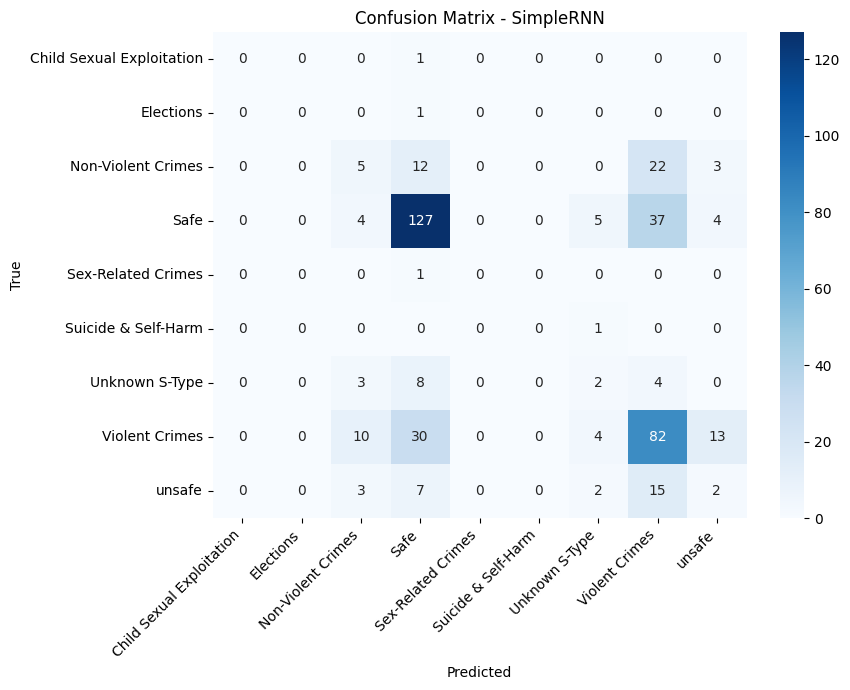

In [40]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - SimpleRNN")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

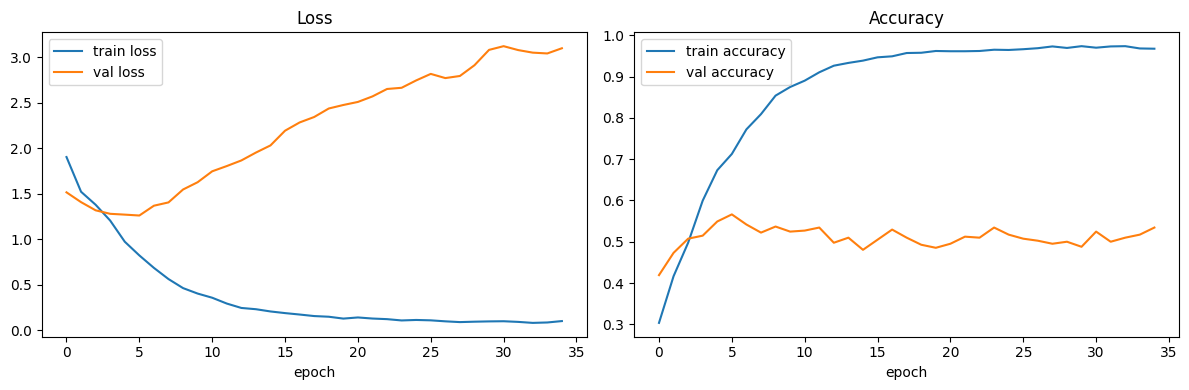

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
